In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn import metrics
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix,ConfusionMatrixDisplay,precision_recall_curve
from sklearn.metrics import precision_recall_fscore_support, precision_score, recall_score, roc_curve, auc,log_loss
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.model_selection import GridSearchCV, train_test_split, StratifiedKFold, learning_curve, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, MinMaxScaler, StandardScaler
from sklearn.calibration import CalibratedClassifierCV
from sklearn.inspection import permutation_importance

import joblib

In football the key target is scoring a goal but goals are rare in a game so they are heavily influenced by luck and don't contain enough information for identifying which team played better or how many goals should have been scored based on the game's chances. For this reason a metric for measuring the probabillity of a goal being scored have been created, the Expected Goal (ExG) value for every shot taken in a game.

So essentially every shot given its circumstances such as its distance and angle to the target, the body part involved, etc has a probability value for leading to a goal. This is important for understanding which team played better based on the total expected goals value it created and which game score would be 'fair'. The total ExG value for a team is just the sum of all its shots' ExG values.



# Loading and Cleaning the data:

The data contain all on ball actions for the top 5 football leagues for the 2018 season.

In [40]:
df_all = pd.read_json('events/events_England.json')
countries = ['Spain','Italy','Germany','France']
for i in countries:
    df = pd.read_json('events/events_'+i+'.json')
    df_all = pd.concat([df_all, df])

df_all.head()

,eventId,subEventName,tags,playerId,positions,matchId,eventName,teamId,matchPeriod,eventSec,subEventId,id
0,8,Simple pass,[{'id': 1801}],25413,"[{'y': 49, 'x': 49}, {'y': 78, 'x': 31}]",2499719,Pass,1609,1H,2.758649,85,177959171
1,8,High pass,[{'id': 1801}],370224,"[{'y': 78, 'x': 31}, {'y': 75, 'x': 51}]",2499719,Pass,1609,1H,4.946850,83,177959172
2,8,Head pass,[{'id': 1801}],3319,"[{'y': 75, 'x': 51}, {'y': 71, 'x': 35}]",2499719,Pass,1609,1H,6.542188,82,177959173
3,8,Head pass,[{'id': 1801}],120339,"[{'y': 71, 'x': 35}, {'y': 95, 'x': 41}]",2499719,Pass,1609,1H,8.143395,82,177959174
4,8,Simple pass,[{'id': 1801}],167145,"[{'y': 95, 'x': 41}, {'y': 88, 'x': 72}]",2499719,Pass,1609,1H,10.302366,85,177959175


Some usefull features for predicting the probability of scoring for a shot are the shots' distance, angle area to target, part of body while there is also the information of the shot being a big chance
 and if the a shot was the result of a counter attack.

In [41]:
def shots_classif(df):

    goals = np.zeros(len(df))
    headed = np.zeros(len(df))
    right = np.zeros(len(df))
    left = np.zeros(len(df))
    distance = np.zeros(len(df))
    angle = np.zeros(len(df))
    time_min = np.zeros(len(df))
    big_opp = np.zeros(len(df))
    counter = np.zeros(len(df))

    y_in = 50-df['positions'].str[0].str['y']
    x_in = 100-df['positions'].str[0].str['x']
    distance = round(np.sqrt((1.05*x_in)**2+(0.68*y_in)**2),2)

    for i in range(0,len(df)):
        for j in df.iloc[i].tags:
            if j['id']==101:
                goals[i] = 1
            elif j['id']==403:
                headed[i] = 1
            elif j['id']==402:
                right[i] = 1
            elif j['id']==401:
                left[i] = 1
            elif j['id']==201:
                big_opp[i] = 1
            elif j['id']==1901:
                counter[i] = 1

    df_new = df.copy()
    df_new['Goal'] = goals
    df_new['Headed'] = headed
    df_new['Right'] = right
    df_new['Left'] = left
    df_new['Distance'] = distance
    df_new['Big_Chance'] = big_opp
    df_new['Counter'] = counter

    goal_half_width = 7.32 * (100 / 68) / 2
    left_post_y = -goal_half_width
    right_post_y = goal_half_width

    angle = (
      np.arctan2(right_post_y - y_in, x_in) -
      np.arctan2(left_post_y - y_in, x_in)
      )
    df_new['Angle'] = round(np.abs(angle),3)

    df_new = df_new.drop(['subEventName','eventId','positions','tags','eventName','subEventId','id','matchPeriod','eventSec',
                          'matchId','teamId'], axis=1)

    return df_new

df_shots = shots_classif(df_all[df_all['eventName']=='Shot'])
df_shots.head()

,playerId,Goal,Headed,Right,Left,Distance,Big_Chance,Counter,Angle
46,25413,1.0,0.0,1.0,0.0,14.01,1.0,0.0,0.583
62,26150,0.0,0.0,0.0,1.0,15.81,1.0,0.0,0.679
91,14763,1.0,1.0,0.0,0.0,4.41,1.0,0.0,1.776
128,7868,0.0,0.0,0.0,1.0,23.06,1.0,0.0,0.318
249,7868,0.0,0.0,1.0,0.0,29.56,1.0,0.0,0.264


The are also usefull data for players' "good foot", since the majority of football players' feet have different level of skill, and the player's individual role. The possible roles are goalkeeper (GK), defender (DF). midfielder (MD) and forward (FW). Another variable that might be usefull is players' height for header is going to be used.

Index(['teamId', 'height', 'role', 'playerId', 'foot', 'shortName'], dtype='object')

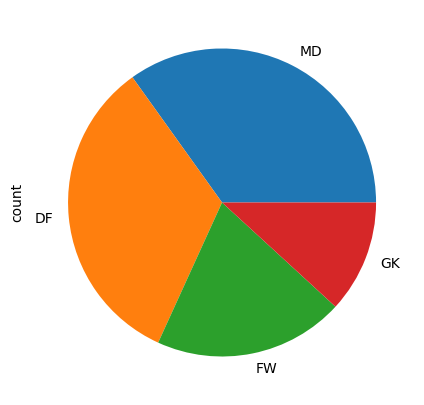

In [42]:
df_teams = pd.read_json('teams.json')
df_players = pd.read_json('players.json')
df_players = df_players.drop(['passportArea', 'weight', 'middleName', 'birthDate', 'birthArea', 'firstName',
                              'lastName','currentNationalTeamId'], axis=1)

df_players = df_players.rename(columns={'currentTeamId': 'teamId', 'wyId': 'playerId'})
roles = []
for i in range(0,len(df_players)):
    roles.append(df_players["role"][i]['code2'])

df_players['role'] = roles
df_players['role'].value_counts().plot.pie(figsize=(5, 5))
df_players.head()
df_players = df_players[df_players['role']!='GK']
df_players.columns

In [43]:
df_players['foot'].value_counts()

,count
foot,
right,2350
left,782
,36
both,5
null,4


Merging the shots' data with the players' data:

In [44]:
ExG_data = pd.merge(df_shots,df_players, on="playerId")
ExG_data['Good_Foot'] = list(((ExG_data['foot']=='left')+(ExG_data['foot']=='both'))*(ExG_data['Right']==1)+
                        ((ExG_data['foot']=='right')+(ExG_data['foot']=='both'))*(ExG_data['Left']==1))
ExG_data = ExG_data.drop(columns=['foot','Left','teamId','playerId','shortName'])
ExG_data.columns

Index(['Goal', 'Headed', 'Right', 'Distance', 'Big_Chance', 'Counter', 'Angle',
       'height', 'role', 'Good_Foot'],
      dtype='object')

The following function creates a table is going to be used for a statistical metrics' summary for valuing the models' performance:

In [45]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def measure_error(y_true, y_pred, label):
    return pd.Series({'accuracy':accuracy_score(y_true, y_pred),
                      'precision': precision_score(y_true, y_pred),
                      'recall': recall_score(y_true, y_pred),
                      'f1': f1_score(y_true, y_pred)},
                      name=label)

The target of this work is to create a model for expected goals given a football actions dataset containing information of shots such as position (Distance, Angle), way of shooting (Headed, Right, Good_Foot), if it is a big chance (Big_Chance), the position of the ball before the shot (Distance, Angle), if it is a counter attack (Counter) and the height of the player shooting (height).

The variable of Big_Chance contain information that are directly included such as defending state and defenders pressure to a shot, so it saves some time from gaining this information from the actions data. It could be usefull to create a model for clasifying the big chances for even further accuracy and understanding of shots' expected values.

Knowing that the majority of the shots are under bad circumstances (~10% probability of scoring) we expect a high number of false negative classifications and thus the target is the expected values of goals coming from every shot. For this reason the key metric of the model's success is going to be its logloss value.

# Exploring the Dataset:

In [46]:
random_state=35

In [47]:
ExG_data.columns

Index(['Goal', 'Headed', 'Right', 'Distance', 'Big_Chance', 'Counter', 'Angle',
       'height', 'role', 'Good_Foot'],
      dtype='object')

We can see that the dataset doesn't have any Nan or empty cells, it is ready for further processing. All columns are numeric except role which need to be converted to dummy variables. From the other numeric columns Headed,Right,Big_Chance,Counter,Good_Foot are categorical variables transformed to numeric already. The target variale is Goal, which is a binary variable.

In [48]:
ExG_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40451 entries, 0 to 40450
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Goal        40451 non-null  float64
 1   Headed      40451 non-null  float64
 2   Right       40451 non-null  float64
 3   Distance    40451 non-null  float64
 4   Big_Chance  40451 non-null  float64
 5   Counter     40451 non-null  float64
 6   Angle       40451 non-null  float64
 7   height      40451 non-null  int64  
 8   role        40451 non-null  object 
 9   Good_Foot   40451 non-null  bool   
dtypes: bool(1), float64(7), int64(1), object(1)
memory usage: 2.8+ MB


The target variable is highly imbalanced and thus weighting has to be considered in all models following.

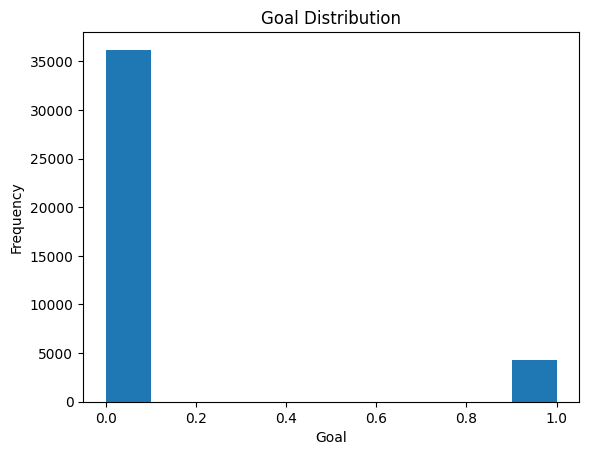

In [49]:
plt.hist(ExG_data['Goal'])
plt.xlabel('Goal')
plt.ylabel('Frequency')
plt.title('Goal Distribution')
plt.show()

Creating dummy variables for the the role column being an object which include 'DF','MD' and 'FW' labels and the 'DF' label is dropped in order to avoid perfect multicollinearity.

In [50]:
ExG_M_Data = pd.get_dummies(ExG_data, columns = ['role'], drop_first=True)
ExG_M_Data.head()

,Goal,Headed,Right,Distance,Big_Chance,Counter,Angle,height,Good_Foot,role_FW,role_MD
0,1.0,0.0,1.0,14.01,1.0,0.0,0.583,175,False,True,False
1,0.0,0.0,0.0,15.81,1.0,0.0,0.679,179,False,False,True
2,1.0,1.0,0.0,4.41,1.0,0.0,1.776,174,False,True,False
3,0.0,0.0,0.0,23.06,1.0,0.0,0.318,175,True,False,True
4,0.0,0.0,1.0,29.56,1.0,0.0,0.264,175,False,False,True


Below we can see the correlation matrix of the whole dataset, as expected way of shooting (right, good foot, headed) and different roles are highly correlated within their categories. Also, distance has high correlation with variables is expected due to common sense. It is already visible that the target variable Goal has highest correlation with distance, angle and big_chance variables.

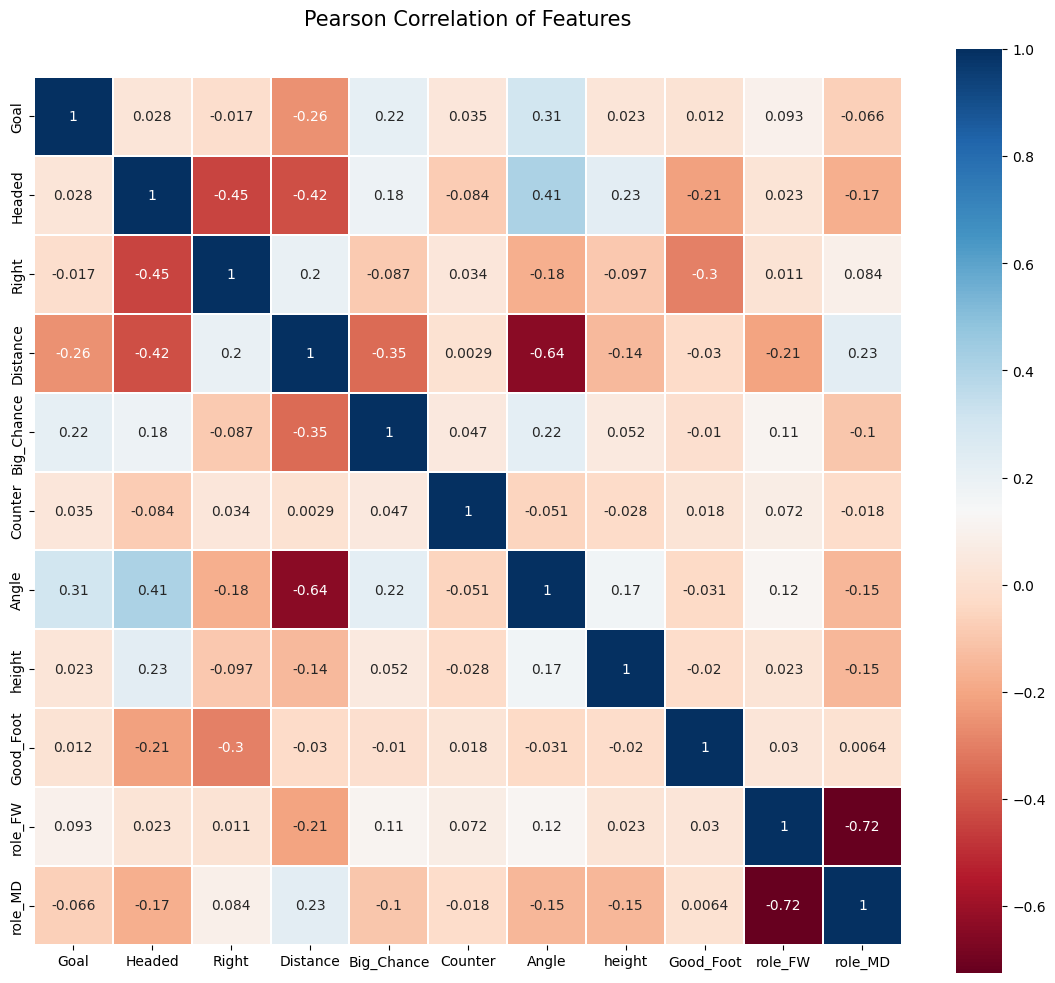

In [51]:
colormap = plt.cm.RdBu
plt.figure(figsize=(14,12))
plt.title('Pearson Correlation of Features', y=1.05, size=15)
sns.heatmap(ExG_M_Data.astype(float).corr(),linewidths=0.1,vmax=1.0,
            square=True, cmap=colormap, linecolor='white', annot=True)
plt.show()

### Spliting the train/test datasets

Splitting the test train data with ensuring same labels' portions in test/train data with the whole dataset:

In [52]:
X_raw = ExG_M_Data.drop('Goal',axis=1)
Y = ExG_M_Data['Goal']

In [53]:
X_raw.columns

Index(['Headed', 'Right', 'Distance', 'Big_Chance', 'Counter', 'Angle',
       'height', 'Good_Foot', 'role_FW', 'role_MD'],
      dtype='object')

In [54]:
X_train, X_test, y_train, y_test = train_test_split( X_raw, Y, test_size=0.2, random_state=random_state)

In [55]:
y_train.value_counts(normalize=True).sort_index()

,proportion
Goal,
0.0,0.893665
1.0,0.106335


In [56]:
y_test.value_counts(normalize=True).sort_index()

,proportion
Goal,
0.0,0.89754
1.0,0.10246


# Modeling the Data:

### Preprocessor:

Creating the preprocessor by scaling the numerical columns by the standard scaler and leaving categorical variables unchanged:

In [57]:
ExG_data.columns

Index(['Goal', 'Headed', 'Right', 'Distance', 'Big_Chance', 'Counter', 'Angle',
       'height', 'role', 'Good_Foot'],
      dtype='object')

In [58]:
numeric_features = ['Distance', 'Angle','height']
categorical_features = ['role_FW','role_MD','Headed', 'Right','Big_Chance', 'Counter','Good_Foot']
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', 'passthrough', categorical_features)
    ]
)

### Logistic Regression:

In [59]:
import time

pipeline_LR = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(random_state=random_state))
])

param_grid = {
    'classifier__C': [0.01,0.1,1,5,10,50,100],
    'classifier__class_weight': ['balanced', {0:1, 1:9},{0:2, 1:6},{0:3, 1:7}]
}

start_time = time.perf_counter()
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

GS_LR = GridSearchCV(pipeline_LR, param_grid, cv=cv,scoring='neg_log_loss')

GS_LR.fit(X_train, y_train)
end_time = time.perf_counter()

In [60]:
model_LS = GS_LR.best_estimator_
print(f" Execution time: {round(end_time - start_time)} seconds,\n Best parameters:",GS_LR.best_params_)

 Execution time: 36 seconds,
 Best parameters: {'classifier__C': 1, 'classifier__class_weight': {0: 3, 1: 7}}


In [61]:
y_train_pred_gr = model_LS.predict(X_train)
y_test_pred_gr = model_LS.predict(X_test)

train_test_gr_error_all = pd.concat([measure_error(y_train, y_train_pred_gr, 'train_LS'),
                                 measure_error(y_test, y_test_pred_gr, 'test_LS')],
                                axis=1)

train_test_gr_error_all

,train_LS,test_LS
accuracy,0.886465,0.884192
precision,0.446189,0.406250
recall,0.280732,0.282268
f1,0.344631,0.333096


Text(0.5, 1.0, 'Confusion Matrix - Train Set')

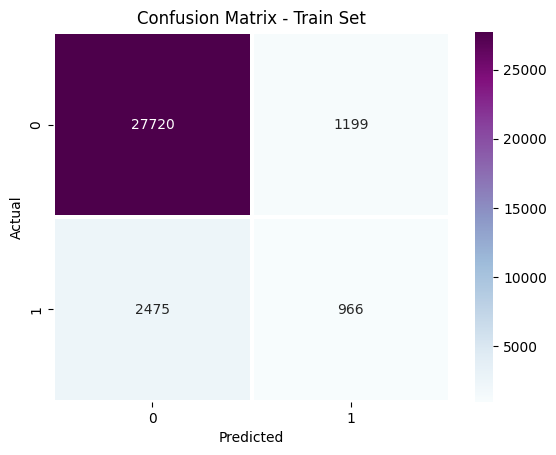

In [62]:
cm_train_xg = confusion_matrix(y_train, y_train_pred_gr)

ax = sns.heatmap(cm_train_xg, annot=True, cmap='BuPu', fmt='g', linewidth=1.5)

ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title('Confusion Matrix - Train Set')

Text(0.5, 1.0, 'Confusion Matrix - Train Set')

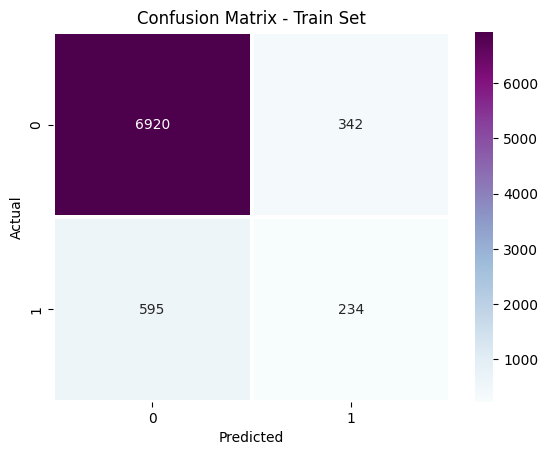

In [63]:
cm_train_xg = confusion_matrix(y_test, y_test_pred_gr)

ax = sns.heatmap(cm_train_xg, annot=True, cmap='BuPu', fmt='g', linewidth=1.5)

ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title('Confusion Matrix - Train Set')

### Decision Tree:

In [64]:
pipeline_DT = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(random_state=random_state))
])

param_grid = {
    'classifier__max_depth':range(5, 25, 3),
    'classifier__max_features': range(5, 14,2),
    'classifier__class_weight': [{0:9, 1:1}, {0:8, 1:2}, {0:7, 1:3}, {0:6, 1:4},'balanced'],
    'classifier__min_samples_leaf' : [5,10,20]
}

start_time = time.perf_counter()

print(f"Execution time: {end_time - start_time} seconds")

GS_DT = GridSearchCV(pipeline_DT, param_grid, cv=cv,verbose = 0,scoring='neg_log_loss')

GS_DT.fit(X_train, y_train)

end_time = time.perf_counter()

Execution time: -979.5772709639996 seconds


In [65]:
model_DT = GS_DT.best_estimator_
print(f" Execution time: {round(end_time - start_time)} seconds,\n Best parameters:",GS_DT.best_params_)

 Execution time: 534 seconds,
 Best parameters: {'classifier__class_weight': {0: 6, 1: 4}, 'classifier__max_depth': 5, 'classifier__max_features': 11, 'classifier__min_samples_leaf': 20}


In [66]:
y_train_pred_gr = model_DT.predict(X_train)
y_test_pred_gr = model_DT.predict(X_test)

train_test_gr_error = pd.concat([measure_error(y_train, y_train_pred_gr, 'train_DT'),
                                 measure_error(y_test, y_test_pred_gr, 'test_DT')],
                                axis=1)
train_test_gr_error_all = pd.concat([train_test_gr_error_all,train_test_gr_error],axis=1)

train_test_gr_error

,train_DT,test_DT
accuracy,0.897713,0.900878
precision,0.750958,0.764706
recall,0.056960,0.047045
f1,0.105889,0.088636


Text(0.5, 1.0, 'Confusion Matrix - Train Set')

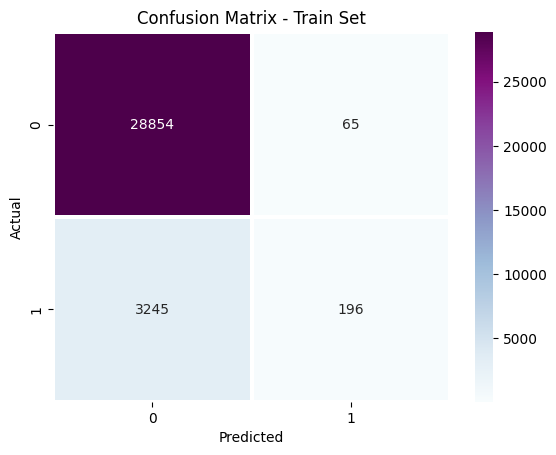

In [67]:
cm_train_xg = confusion_matrix(y_train, y_train_pred_gr)
ax = sns.heatmap(cm_train_xg, annot=True, cmap='BuPu', fmt='g', linewidth=1.5)

ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title('Confusion Matrix - Train Set')


Text(0.5, 1.0, 'Confusion Matrix - Train Set')

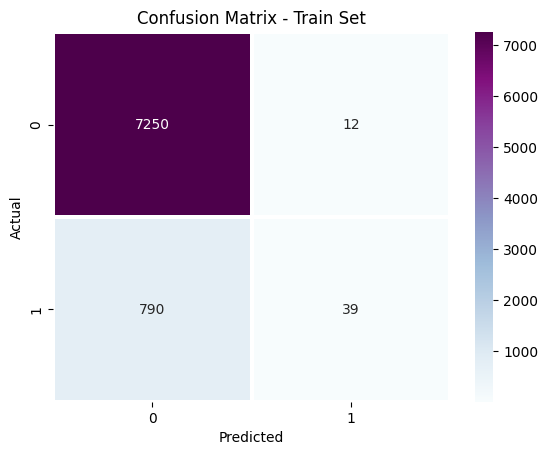

In [68]:
cm_train_xg = confusion_matrix(y_test, y_test_pred_gr)

ax = sns.heatmap(cm_train_xg, annot=True, cmap='BuPu', fmt='g', linewidth=1.5)

ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title('Confusion Matrix - Train Set')

### Random Forest:

In [69]:
pipeline_RF = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=random_state))
])

param_grid = {
    'classifier__n_estimators':['sqrt', "log2", None],
    'classifier__n_estimators':[100, 500],
    'classifier__max_depth': [5, 10, 20, 25],
    "classifier__class_weight": [ None , "balanced"],
    'classifier__min_samples_leaf' : [3,10,20],
    "classifier__min_samples_split": [5, 10, 20]}

start_time = time.perf_counter()

GS_RF = GridSearchCV(pipeline_RF, param_grid, cv=cv,verbose = 0,scoring='neg_log_loss')

GS_RF.fit(X_train, y_train)

end_time = time.perf_counter()

In [70]:
model_RF = CalibratedClassifierCV(GS_RF.best_estimator_, method='sigmoid', cv=5)
model_RF.fit(X_train, y_train)
print(f" Execution time: {round(end_time - start_time)} seconds,\n Best parameters:",GS_RF.best_params_)

 Execution time: 4437 seconds,
 Best parameters: {'classifier__class_weight': None, 'classifier__max_depth': 10, 'classifier__min_samples_leaf': 20, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 500}


In [71]:
y_train_pred_gr = model_RF.predict(X_train)
y_test_pred_gr = model_RF.predict(X_test)

train_test_gr_error = pd.concat([measure_error(y_train, y_train_pred_gr, 'train_RF'),
                                 measure_error(y_test, y_test_pred_gr, 'test_RF')],
                                axis=1)

train_test_gr_error_all = pd.concat([train_test_gr_error_all,train_test_gr_error],axis=1)

train_test_gr_error

,train_RF,test_RF
accuracy,0.900618,0.900260
precision,0.624309,0.547414
recall,0.164196,0.153197
f1,0.260009,0.239397


Text(0.5, 1.0, 'Confusion Matrix - Train Set')

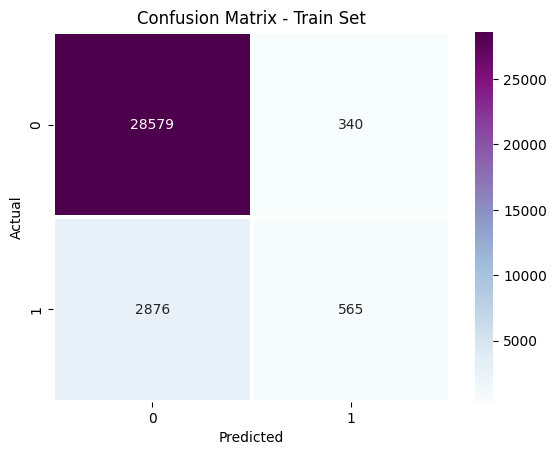

In [72]:

cm_train_xg = confusion_matrix(y_train, y_train_pred_gr)
ax = sns.heatmap(cm_train_xg, annot=True, cmap='BuPu', fmt='g', linewidth=1.5)

ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title('Confusion Matrix - Train Set')

Text(0.5, 1.0, 'Confusion Matrix - Train Set')

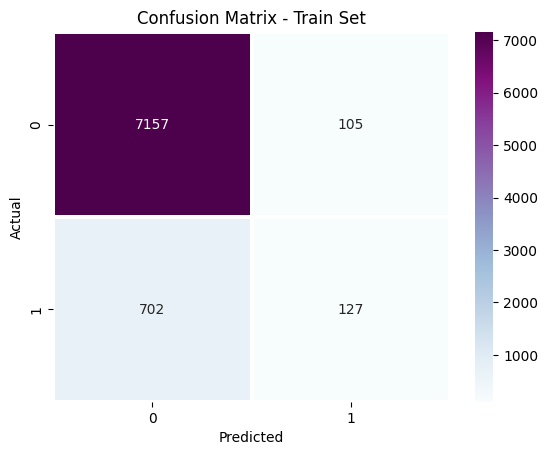

In [73]:
cm_test_xg = confusion_matrix(y_test, y_test_pred_gr)
ax = sns.heatmap(cm_test_xg, annot=True, cmap='BuPu', fmt='g', linewidth=1.5)

ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title('Confusion Matrix - Train Set')

###XGBoost:

In [74]:
pipeline_XGB = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(objective='binary:logistic',eval_metric='logloss',random_state=random_state))
])

param_grid = {
    'classifier__n_estimators': [300, 600],
    'classifier__max_depth': [3, 5, 7],
    'classifier__learning_rate': [0.05, 0.5],
    'classifier__min_child_weight': [1, 5, 10],
    'classifier__subsample': [0.8, 1.0],
    'classifier__colsample_bytree': [0.8, 1.0],
    'classifier__scale_pos_weight': [None, 8.5],
    'classifier__gamma': [1 , 5, 10]
}

start_time = time.perf_counter()

GS_XGB = GridSearchCV(pipeline_XGB, param_grid, cv=cv,verbose = 0,scoring='neg_log_loss')

GS_XGB.fit(X_train, y_train)

end_time = time.perf_counter()

In [95]:
print(f" Execution time: {round(end_time - start_time)} seconds,\n Best parameters:",GS_XGB.best_params_)

 Execution time: 4172 seconds,
 Best parameters: {'classifier__colsample_bytree': 1.0, 'classifier__gamma': 5, 'classifier__learning_rate': 0.05, 'classifier__max_depth': 5, 'classifier__min_child_weight': 1, 'classifier__n_estimators': 600, 'classifier__scale_pos_weight': None, 'classifier__subsample': 0.8}


In [96]:
from sklearn.calibration import CalibratedClassifierCV

model_XGB = CalibratedClassifierCV(GS_XGB.best_estimator_ , method='sigmoid', cv=5)
model_XGB.fit(X_train, y_train)

CalibratedClassifierCV(cv=5,
                       estimator=Pipeline(steps=[('preprocessor',
                                                  ColumnTransformer(transformers=[('num',
                                                                                   StandardScaler(),
                                                                                   ['Distance',
                                                                                    'Angle',
                                                                                    'height']),
                                                                                  ('cat',
                                                                                   'passthrough',
                                                                                   ['role_FW',
                                                                                    'role_MD',
                                                                                    'Headed',
                                                                                    'Right',
                                                                                    'Big_Chance',
                                                                                    'Counter',
                                                                                    'Good_Foot'])])),
                                                 ('classifier',
                                                  XGBClassifier(base_score=None,
                                                                booster=None,
                                                                callbacks=None,
                                                                colsample_bylevel=None...
                                                                feature_weights=None,
                                                                gamma=5,
                                                                grow_policy=None,
                                                                importance_type=None,
                                                                interaction_constraints=None,
                                                                learning_rate=0.05,
                                                                max_bin=None,
                                                                max_cat_threshold=None,
                                                                max_cat_to_onehot=None,
                                                                max_delta_step=None,
                                                                max_depth=5,
                                                                max_leaves=None,
                                                                min_child_weight=1,
                                                                missing=nan,
                                                                monotone_constraints=None,
                                                                multi_strategy=None,
                                                                n_estimators=600,
                                                                n_jobs=None,
                                                                num_parallel_tree=None, ...))]))

In [97]:
y_train_pred_gr = model_XGB.predict(X_train)
y_test_pred_gr = model_XGB.predict(X_test)

train_test_gr_error = pd.concat([measure_error(y_train, y_train_pred_gr, 'train_XGB'),
                                 measure_error(y_test, y_test_pred_gr, 'test_XGB')],
                                axis=1)

train_test_gr_error_all = pd.concat([train_test_gr_error_all,train_test_gr_error],axis=1)

train_test_gr_error

,train_XGB,test_XGB
accuracy,0.898826,0.901125
precision,0.596532,0.568720
recall,0.149956,0.144753
f1,0.239666,0.230769


Text(0.5, 1.0, 'Confusion Matrix - Train Set')

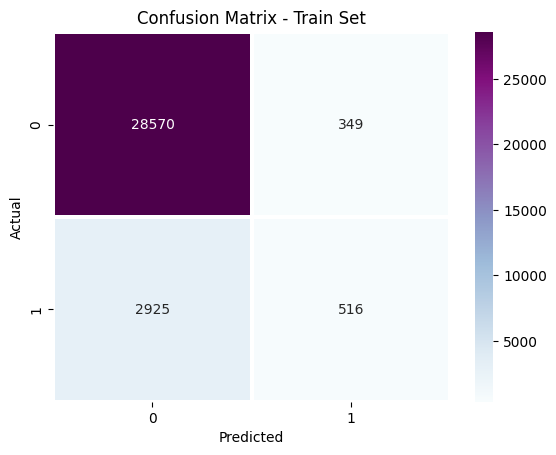

In [98]:
cm_train_xg = confusion_matrix(y_train, y_train_pred_gr)
ax = sns.heatmap(cm_train_xg, annot=True, cmap='BuPu', fmt='g', linewidth=1.5)

ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title('Confusion Matrix - Train Set')

Text(0.5, 1.0, 'Confusion Matrix - Train Set')

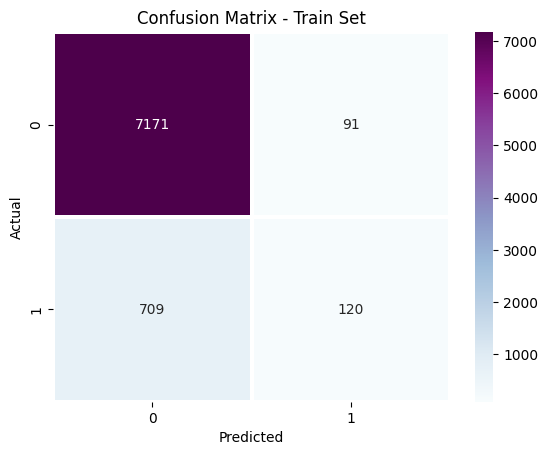

In [99]:
cm_test_xg = confusion_matrix(y_test, y_test_pred_gr)
ax = sns.heatmap(cm_test_xg, annot=True, cmap='BuPu', fmt='g', linewidth=1.5)

ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title('Confusion Matrix - Train Set')

# TESTING:

### Generic Classification Metrics:

Below the accuracy, precision, recall and f1 of all models for the training and testing datasets are presented. It can be seen that models do not show signs of overfitting while they all have a similar accuracy close to the proportion of non goal shots in the dataset (~89.5%). The Decision Tree model has a recall value much lower than a non-informative model so it is already clear that is not an acceptable option.

The LS and RF models have a higher f1 score than XGB due to high recall values but it is not an important metric for the case examined in this notebook. In a classification problem these values could be the main metric for picking the best model but in our case the log loss is the most important one due to the target being the calculation of expected values. Due to the majority of the shots being under bad circumstances a low recall is expected so the XBG model seems to perform best so far.

In [80]:
train_test_gr_error_all

,train_LS,test_LS,train_DT,test_DT,train_RF,test_RF,train_XGB,test_XGB
accuracy,0.886465,0.884192,0.897713,0.900878,0.900618,0.900260,0.898826,0.901125
precision,0.446189,0.406250,0.750958,0.764706,0.624309,0.547414,0.596532,0.568720
recall,0.280732,0.282268,0.056960,0.047045,0.164196,0.153197,0.149956,0.144753
f1,0.344631,0.333096,0.105889,0.088636,0.260009,0.239397,0.239666,0.230769


Below we see the rank of the tested models based on the logloss values on the test dataset with XGB being the best model, RF following close and then the the DT and LS follow with big differences in logloss terms from the top 2 models. The Disicion Tree shows a very bad performance not only on logloss mean value but on its variance as well. It is clear that the XGB model is the best one for our goal.

In [81]:
from sklearn.model_selection import cross_val_score
from sklearn.metrics import log_loss

scores_LS = -cross_val_score(model_LS,X_test,y_test,scoring="neg_log_loss",cv=5)
scores_DT = -cross_val_score(model_DT,X_test,y_test,scoring="neg_log_loss",cv=5)
scores_RF = -cross_val_score(model_RF,X_test,y_test,scoring="neg_log_loss",cv=5)
scores_XGB = -cross_val_score(model_XGB,X_test,y_test,scoring="neg_log_loss",cv=5)

In [82]:
logloss_mean = [scores_LS.mean(), scores_DT.mean(), scores_RF.mean(), scores_XGB.mean()]
logloss_std = [scores_LS.std(), scores_DT.std(), scores_RF.std(), scores_XGB.std()]
models = ["LS","DT","RF","XGB"]
log_loss_table = pd.DataFrame({"model": models,"test_logloss_mean": logloss_mean,"test_logloss_std": logloss_std}).sort_values(by="test_logloss_mean")
log_loss_table.reset_index(drop=True)

,model,test_logloss_mean,test_logloss_std
0,XGB,0.275364,0.009267
1,RF,0.276592,0.009621
2,DT,0.287086,0.029800
3,LS,0.297184,0.008157


Below the ROC and Presicion-Recall curves as shown although they are not very usefull (especially the ROC as it can be seen below as well) for expected values modeling with a highly imbalanced dataset such as the one explored here. In the Presicion-Recall in the range of recall being higher than 0.105 is clear the XGB outperforms the rest of the models for the maojority of reasonable recall values range.

In [83]:
y_pred_proba_LS = model_LS.predict_proba(X_test)[:, 1]
y_pred_proba_DT = model_DT.predict_proba(X_test)[:, 1]
y_pred_proba_RF = model_RF.predict_proba(X_test)[:, 1]
y_pred_proba_XGB = model_XGB.predict_proba(X_test)[:, 1]

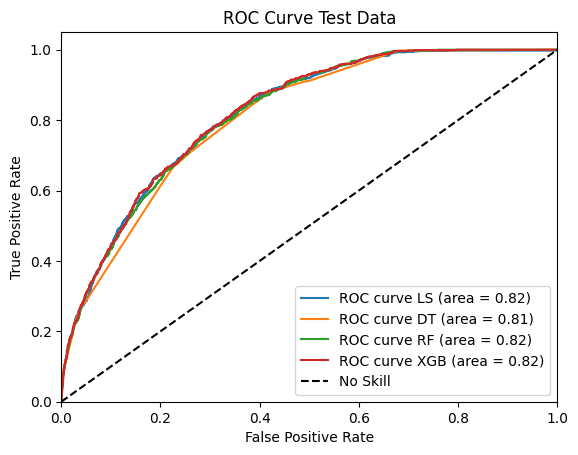

In [84]:
fpr_LS, tpr_LS, thresholds = roc_curve(y_test, y_pred_proba_LS)
roc_auc_LS = auc(fpr_LS, tpr_LS)

fpr_DT, tpr_DT, thresholds = roc_curve(y_test, y_pred_proba_DT)
roc_auc_DT = auc(fpr_DT, tpr_DT)

fpr_RF, tpr_RF, thresholds = roc_curve(y_test, y_pred_proba_RF)
roc_auc_RF = auc(fpr_RF, tpr_RF)

fpr_XGB, tpr_XGB, thresholds = roc_curve(y_test, y_pred_proba_XGB)
roc_auc_XGB = auc(fpr_XGB, tpr_XGB)

plt.figure()
plt.plot(fpr_LS, tpr_LS, label='ROC curve LS (area = %0.2f)' % roc_auc_LS)
plt.plot(fpr_DT, tpr_DT, label='ROC curve DT (area = %0.2f)' % roc_auc_DT)
plt.plot(fpr_RF, tpr_RF, label='ROC curve RF (area = %0.2f)' % roc_auc_RF)
plt.plot(fpr_XGB, tpr_XGB, label='ROC curve XGB (area = %0.2f)' % roc_auc_XGB)
plt.plot([0, 1], [0, 1], 'k--', label='No Skill')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Test Data')
plt.legend()
plt.show()

In [85]:
precision_LS, recall_LS, thresholds_LS = precision_recall_curve(y_test, y_pred_proba_LS)
precision_DT, recall_DT, thresholds_DT = precision_recall_curve(y_test, y_pred_proba_DT)
precision_RF, recall_RF, thresholds_RF = precision_recall_curve(y_test, y_pred_proba_RF)
precision_XGB, recall_XGB, thresholds = precision_recall_curve(y_test, y_pred_proba_XGB)

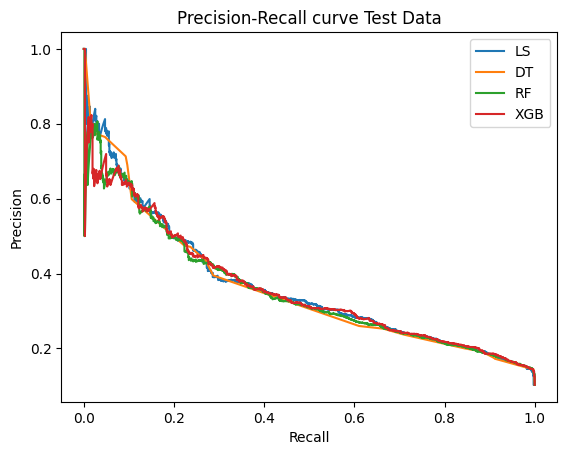

In [86]:
plt.plot(recall_LS, precision_LS)
plt.plot(recall_DT, precision_DT)
plt.plot(recall_RF, precision_RF)
plt.plot(recall_XGB, precision_XGB)

plt.ylabel("Precision")
plt.xlabel("Recall")
plt.title("Precision-Recall curve Test Data")
plt.legend(["LS",'DT','RF','XGB'])

The feature importance through permutations is explored for all models. It is clear that the most important variables explaining most of the data for all 4 models are big chance, distance, angle and the headed. This result is also a sanity test for the modeling results, since it is common sense that the closer to the target and the better the angle you have a shot the higher the probability of scoring while the big_chance variable covers information that is not fully captured from the dataset such as opponents positions and movements. The headed feature is also really important which is expected since headers occurs close to the target inside the box, while in these areas footed shots are much easier to be scored for most cases.

The two best models XGB and RF agree in terms of feature importance for almost all the features which is expected due to the mathematical similarity of the algorithms.

The overall conclusion is that the XGBoost model is the best case of getting Expected Goals from the given dataset.

In [87]:
result_LS = permutation_importance(model_LS, X_test, y_test, n_repeats=20, random_state=random_state,scoring="neg_log_loss")

result_DT = permutation_importance(model_DT, X_test, y_test, n_repeats=20, random_state=random_state,scoring="neg_log_loss")

result_RF = permutation_importance(model_RF, X_test, y_test, n_repeats=20, random_state=random_state,scoring="neg_log_loss")

result_XGB = permutation_importance(model_XGB, X_test, y_test, n_repeats=20, random_state=random_state,scoring="neg_log_loss",)

importances_LS = result_LS.importances_mean
importances_DT = result_DT.importances_mean
importances_RF = result_RF.importances_mean
importances_XGB = result_XGB.importances_mean

sorted_idx_LS = np.argsort(importances_LS)
sorted_idx_DT = np.argsort(importances_DT)
sorted_idx_RF = np.argsort(importances_RF)
sorted_idx_XGB = np.argsort(importances_XGB)


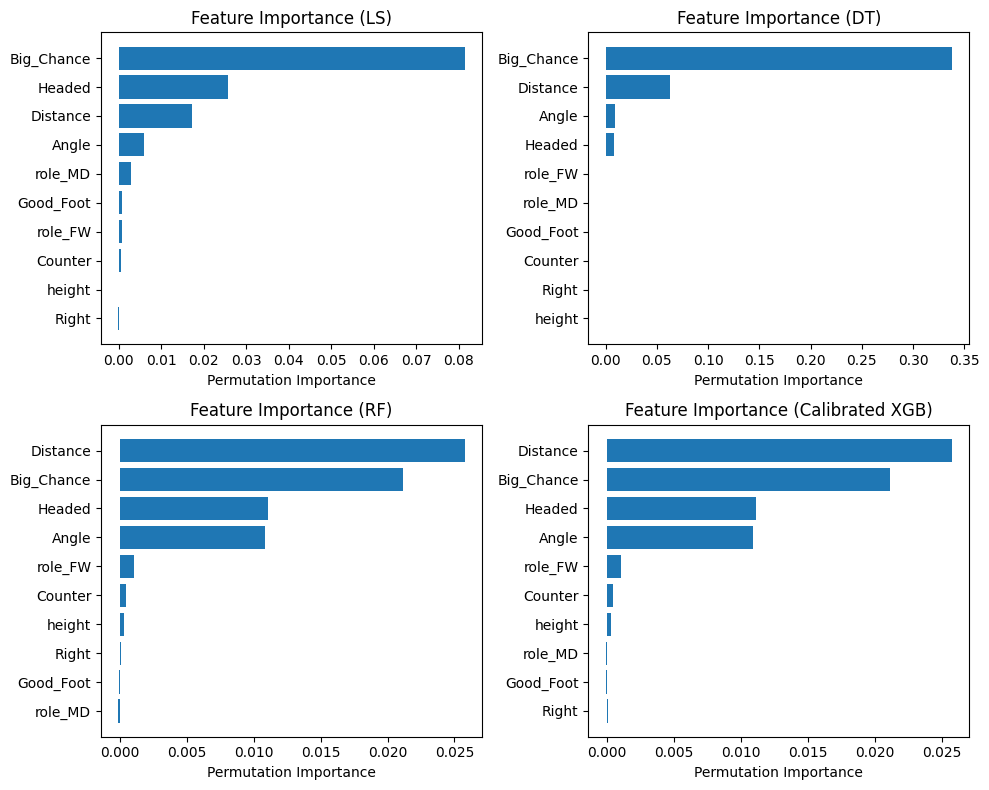

In [88]:
feature_names = X_test.columns

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
ax1 = axes[0, 0]
ax2 = axes[0, 1]
ax3 = axes[1, 0]
ax4 = axes[1, 1]

ax1.barh(feature_names[sorted_idx_LS], importances_LS[sorted_idx_LS])
ax1.set_xlabel("Permutation Importance")
ax1.set_title("Feature Importance (LS)")

ax2.barh(feature_names[sorted_idx_DT], importances_DT[sorted_idx_DT])
ax2.set_xlabel("Permutation Importance")
ax2.set_title("Feature Importance (DT)")

ax3.barh(feature_names[sorted_idx_RF], importances_RF[sorted_idx_RF])
ax3.set_xlabel("Permutation Importance")
ax3.set_title("Feature Importance (RF)")

ax4.barh(feature_names[sorted_idx_XGB], importances_RF[sorted_idx_XGB])
ax4.set_xlabel("Permutation Importance")
ax4.set_title("Feature Importance (Calibrated XGB)")

plt.tight_layout()
plt.show()

### ExG values vs Observations:

The ExG predictions from each model has to be tested against the goal rate observed in the data for each ExG value, which practically is being done by binning the ExG values of all the shots and comparing them with the rate of goal of these shots.

In [89]:
ExG_M_Data['ExG_LS'] = model_LS.predict_proba(ExG_M_Data.drop('Goal', axis = 1))[:, 1]
ExG_M_Data['ExG_DT'] = model_DT.predict_proba(ExG_M_Data.drop('Goal', axis = 1))[:, 1]
ExG_M_Data['ExG_RF'] = model_RF.predict_proba(ExG_M_Data.drop('Goal', axis = 1))[:, 1]
ExG_M_Data['ExG_XGB'] = model_XGB.predict_proba(ExG_M_Data.drop('Goal', axis = 1))[:, 1]

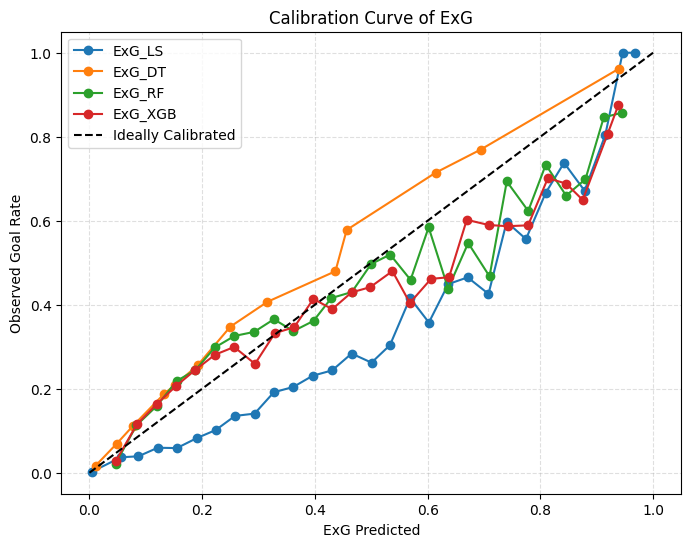

In [90]:
df = ExG_M_Data.copy()
models_list = ['ExG_LS','ExG_DT','ExG_RF','ExG_XGB']

plt.figure(figsize=(8,6))

for i in models_list:
  bins = np.linspace(0, 1, 30)
  df["bin"] = pd.cut(df[i], bins=bins, include_lowest=True) #,duplicates="drop")
  result = df.groupby("bin", observed=True)["Goal"].mean()
  centers = df.groupby("bin", observed=True)[i].mean()
  plt.plot(centers, result, marker="o")


plt.plot([0,1], [0,1],linestyle='dashed', color = 'black')
plt.xlabel("ExG Predicted")
plt.ylabel("Observed Goal Rate")
plt.title("Calibration Curve of ExG")
plt.legend(models_list+['Ideally Calibrated'])
plt.grid(True, linestyle='--', alpha=0.4)

plt.show()

Using the above plot for judging the models' performance is not reasonable since the ExG values have extremely skewed distributions towards small values, something that is expected knowing that the majority of shots are bad shots. This can be shown in the histograms below, the calibration curves has to be adjusted by bins respective to the data's quantiles.

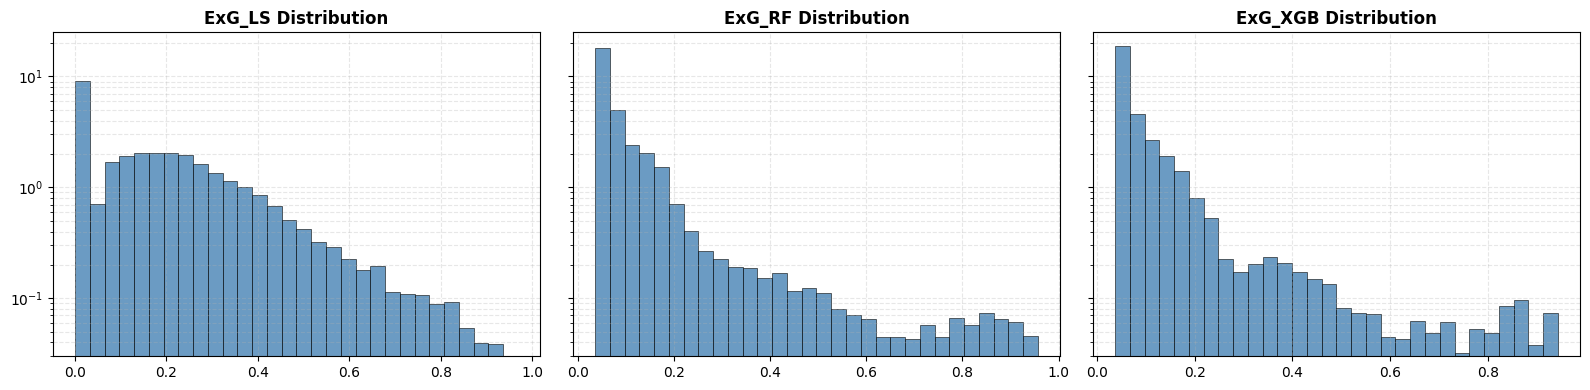

In [91]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=True)

models_list = ['ExG_LS','ExG_RF','ExG_XGB']
k = 0

for i in models_list:
  axes[k].hist(df[i],bins=30, density=True, alpha=0.8,
        color="steelblue",
        edgecolor="black",
        linewidth=0.5, log = True)
  axes[k].set_title(i + " Distribution", fontsize=12, fontweight="bold")
  axes[k].grid(True, which="both", linestyle="--", alpha=0.3)
  k += 1

plt.ylim(0.03,25)
plt.tight_layout()
plt.show()

/tmp/ipykernel_200/3230885768.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  result = df.groupby("bin")["Goal"].mean()
/tmp/ipykernel_200/3230885768.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  centers = df.groupby("bin")[i].mean()


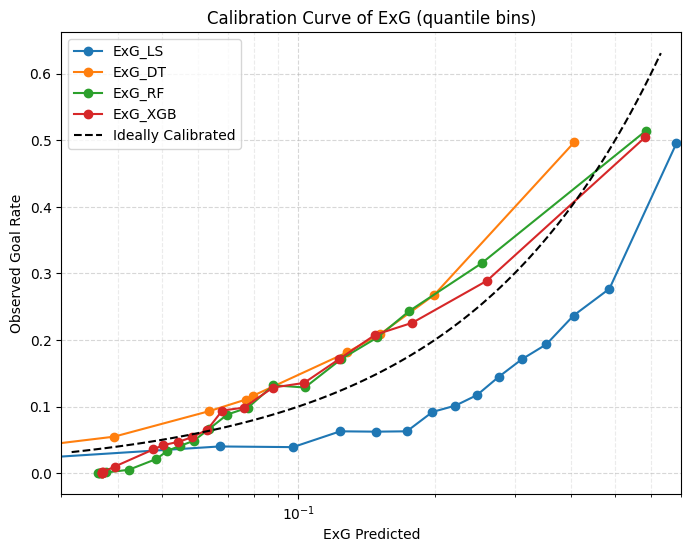

,model,Min Exg Value,Max Exg Value
0,ExG_LS,0.000003,0.968590
1,ExG_DT,0.000000,0.938776
2,ExG_RF,0.036061,0.956746
3,ExG_XGB,0.036807,0.943361


In [92]:
import matplotlib.ticker as mtick

min_values = []
max_values = []

models_list = ['ExG_LS','ExG_DT','ExG_RF','ExG_XGB']
plt.figure(figsize=(8,6))

for i in models_list:
  bins = np.quantile(df[i], np.linspace(0, 1, 21))
  df["bin"] = pd.cut(df[i], bins=bins, include_lowest=True,duplicates="drop")
  result = df.groupby("bin")["Goal"].mean()
  centers = df.groupby("bin")[i].mean()
  plt.plot(centers, result, marker="o")

  min_values.append(df[i].min())
  max_values.append(df[i].max())

x = np.logspace(-1.5, -0.2, 100)
y = x
plt.plot(x, y,linestyle='dashed',color='black')
plt.xlabel("ExG Predicted")
plt.ylabel("Observed Goal Rate")
plt.title("Calibration Curve of ExG (quantile bins)")
plt.legend(models_list+['Ideally Calibrated'])
plt.xscale('log')
plt.xlim(0.03,0.7)
#plt.grid(True, linestyle='--', log = True) #, alpha=0.4)

ax = plt.gca()

ax.grid(True, which='major', linestyle='--', alpha=0.5)
ax.grid(True, which='minor', linestyle='--', alpha=0.25)

ax.xaxis.set_minor_locator(mtick.LogLocator(subs='auto'))

plt.show()

pd.DataFrame({"model": models_list,"Min Exg Value": min_values,"Max Exg Value": max_values})


It's clear that the XGBoost model is the best fot calculating ExG values althought the RandomForest one is close. A problematic behavior observed is the minimum value of the best 2 models being 3.6-3.7%, which seems unreasonable knowing that some shots are under circumastances that justify much closer to zero ExG values. This issue can arrise due to the limitations of these two algorithms, so there is the need to further explore an ExG model done with a more complicated modeling algortihm such as NN.